<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/Assignment_3_ANOVA_Template(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - ANOVA

5PAM2024 - Statistical Modelling

Camille Arnold

---

A randomised controlled trial was conducted to evaluate the efficacy of two novel pharmaceutical compounds (Drug A, Drug B) against a Placebo Control. To determine the most effective delivery method, two administration strategies (Strategy 1, Strategy 2) were employed across all three groups. Efficacy is measured in relative units; higher scores indicate better clinical outcomes. Trial data are given in a CSV file in the following form:

$$
\begin{array}{lccc}
&  \text{Drug A} & \text{Drug B} & \text{Control} \\ \hline
& y_{111} & y_{211} & y_{311} \\
\text{Strategy 1} & \vdots & \vdots & \vdots \\
& y_{11n} & y_{21n} & y_{31n} \\ \hline
& y_{121} & y_{221} & y_{321} \\
\text{Strategy 2} & \vdots & \vdots & \vdots \\
& y_{12n} & y_{22n} & y_{32n} \\ \hline
\end{array}
$$


Your tasks are:

<p>
    
1. **Model Specification & Diagnostics**
    - **1.1.** Provide descriptive statistics (mean and standard deviation) for all treatment groups. Create a boxplot to visualise your data. **(1 mark)**
    - **1.2.** Evaluate the assumptions of ANOVA using Shapiro-Wilk test for normality and Bartlett’s test for equality of variances. **(1 mark)**
    - **1.3.** Produce residuals plots to visually assess the validity of the ANOVA assumptions. **(1 mark)**
    - **1.4.** Produce an interaction plot to visually assess whether the additive model is sufficient or if the interaction model is required to describe the data. **(1 mark)**
    - For each task, briefly explain your findings.
    - You can use all built-in statistical functions to complete this part.
</p>
<p>
2. **Hypothesis Testing (Two-Way ANOVA).** Using α=0.05, determine if there are statistically significant differences:
    - **2.1.** Among the three treatment groups (Main Effect of Treatment). **(2 marks)**
    - **2.2.** Between the two administration strategies (Main Effect of Strategy). **(2 marks)**
    - **2.3.** Between the specific combinations of drug and strategy (Interaction Effect). **(2 marks)**
    - All necessary quantities in this part must be computed using formulas derived in lectures, without using any built-in statistical functions. Then use built-in statistical functions to verify your results. **(1 mark)**
    - For each test, state the null (H0​) and alternative (H1​) hypotheses. Then state your decision and provide a one-sentence interpretation of what this means for the study's variables.
</p>
<p>
3. **Planned Linear Contrasts.** Regardless of the ANOVA F-test results, use the Treatment factor to test the following specific clinical hypotheses (using α=0.05):
    - **3.1.** Contrast 1: Is the average effect of the two drugs significantly different from the Control group? **(2 marks)**
    - **3.2.** Contrast 2: Is there a significant difference in efficacy between Drug A and Drug B? **(2 marks)**
    - All necessary quantities in this part must be computed using formulas derived in lectures, without using any built-in statistical functions. Then use built-in statistical functions to verify your results. **(1 mark)**
    - For each test, state the null (H0​) and alternative (H1​) hypotheses.  Then state your decision and provide a one-sentence interpretation of what this means for the study's variables.
</p>
4. **Clinical Interpretation**
    - Write a brief conclusion advising the hospital on the "Optimal Treatment Strategy." Does the best drug depend on the administration strategy used? **(2 marks)**

Clarity of R code and the overall report quality. **(2 marks)**

**Total: 20 marks.**

---

## 1. Model Specification & Diagnostics

In [ ]:
#importing data
data = read.csv('https://raw.githubusercontent.com/uqglmn/sm/refs/heads/main/A3/A3_01.csv')
head(data)

#specify the categorical (strategy)
data$Strategy = as.factor(data$Strategy)

,Strategy,DrugA,DrugB,Control
,<chr>,<dbl>,<dbl>,<dbl>
1,S1,8.98,12.19,4.27
2,S1,5.78,10.93,5.70
3,S1,6.93,8.25,5.72
4,S1,5.45,11.94,4.44
5,S1,4.86,9.73,5.14
6,S1,5.26,11.81,5.06


In [ ]:
mean(data$DrugA)
mean(data$DrugB)
mean(data$Control)

sd(data$DrugA)
sd(data$DrugB)
sd(data$Control)

[1] 5.872857

[1] 10.23643

[1] 4.72

[1] 2.121851

[1] 1.708819

[1] 1.237539

In [ ]:
a = 3
b = 2
n = nrow(data)/b
N = a * b * n
N

[1] 84

In [ ]:
df = cbind(stack(data[,2:4]), rep(data[,1], a))
colnames(df) = c('score', 'drug', 'strategy')
head(df)

,score,drug,strategy
,<dbl>,<fct>,<fct>
1,8.98,DrugA,S1
2,5.78,DrugA,S1
3,6.93,DrugA,S1
4,5.45,DrugA,S1
5,4.86,DrugA,S1
6,5.26,DrugA,S1


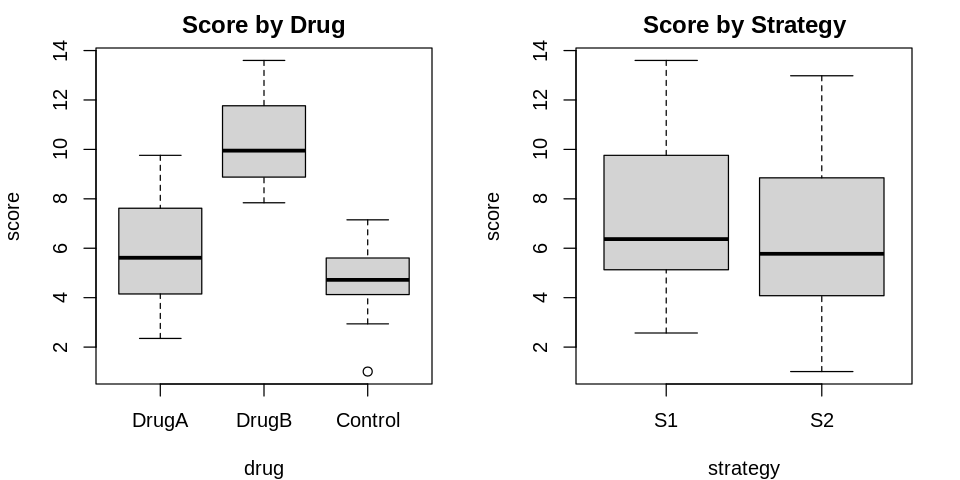

In [ ]:
options(repr.plot.width=8, repr.plot.height=4)
par(mar=c(4,4,2,2), mfrow=c(1,2))

boxplot(score~drug, main = 'Score by Drug', data = df)
boxplot(score~strategy, main = 'Score by Strategy', data = df)



In [ ]:
model_add = aov(score~drug + strategy, data=df)

In [ ]:
#shapiro wilk tests for a normal distribution
shapiro.test(residuals(model_add))

#bartlett tests for equal variance
bartlett.test(score~drug,data=df)


	Shapiro-Wilk normality test

data:  residuals(model_add)
W = 0.98444, p-value = 0.4081



	Bartlett test of homogeneity of variances

data:  score by drug
Bartlett's K-squared = 7.3837, df = 2, p-value = 0.02493


*   Residuals are normally distributed (Shapiro Wilk is close to 0.4)
*   Variability between groups differs



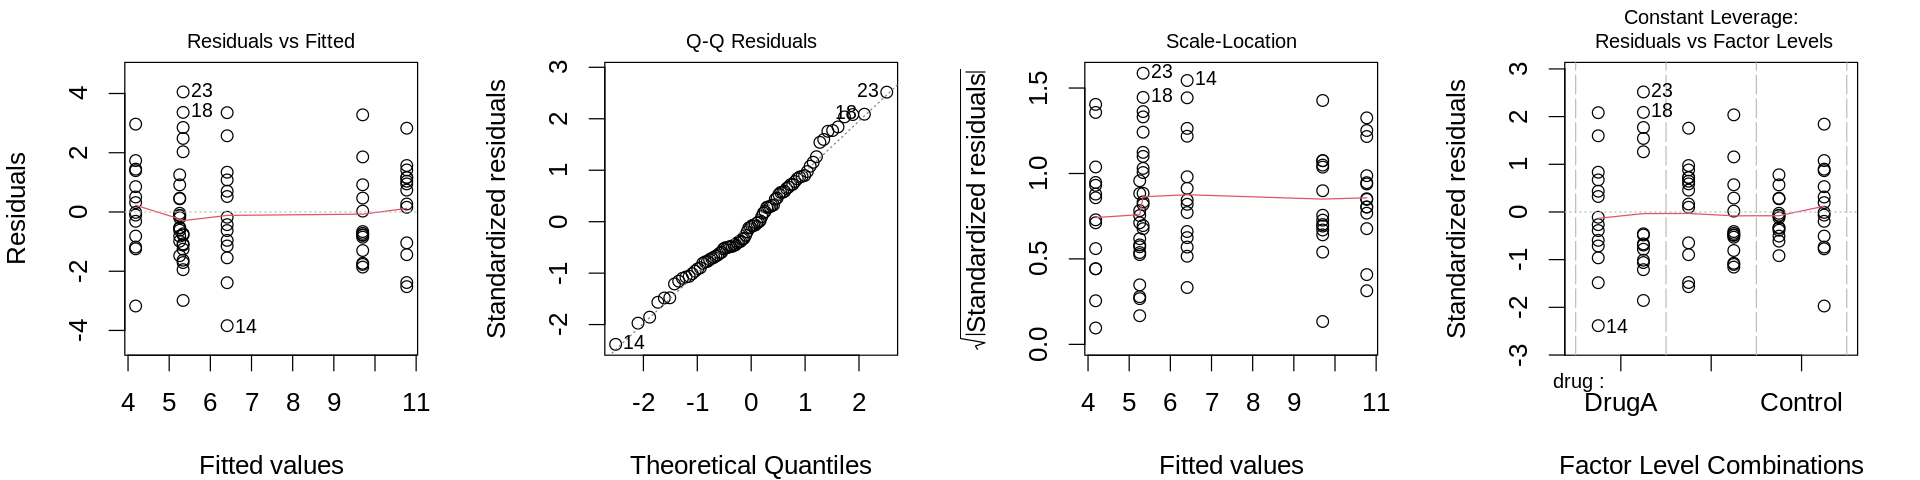

In [ ]:
options(repr.plot.width=16, repr.plot.height=4)
par(mfrow=c(1,4), mar=c(4,4,2,2), cex=1.3)

plot(model_add)

Nothing unusual, resume.

Creating the 2 way anova model

In [ ]:
model_2w = aov(score ~ drug * strategy, data = df)

Interaction Plot

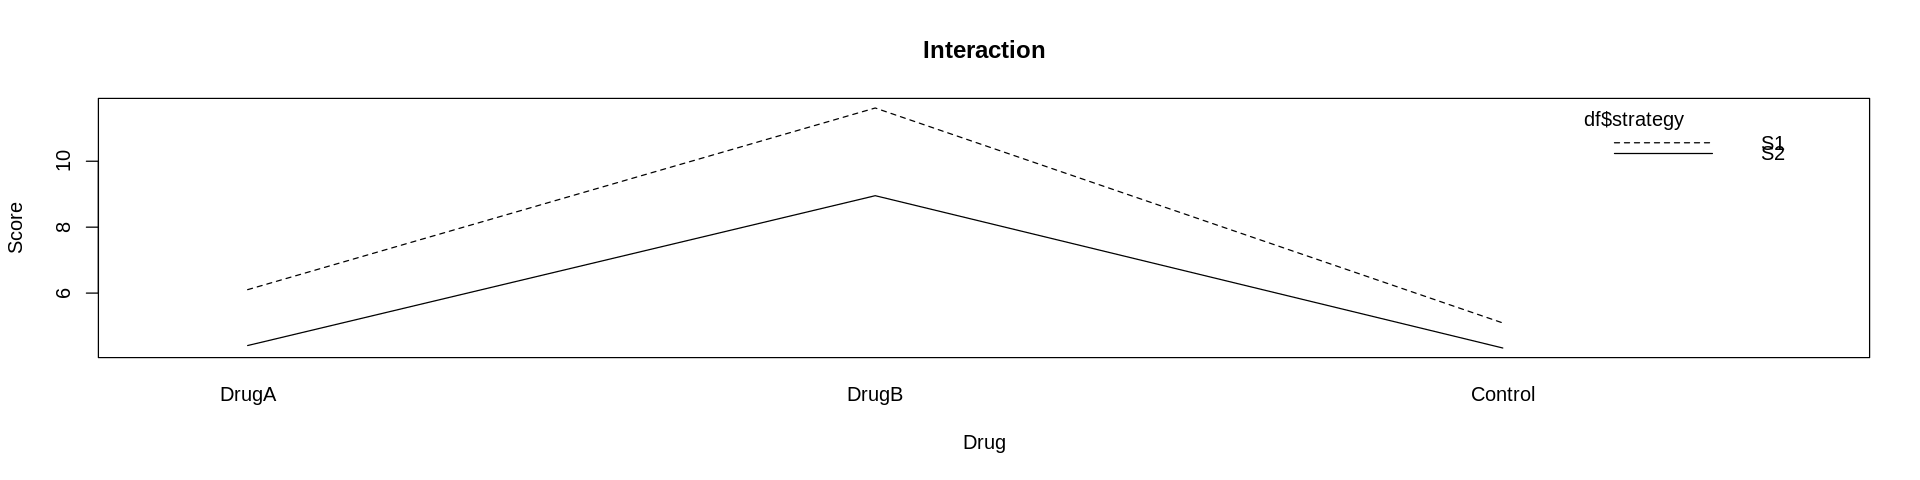

In [ ]:
interaction.plot(x.factor = df$drug,
                 trace.factor = df$strategy,
                 response = df$score,
                 fun = median,
                 ylab = 'Score',
                 xlab = 'Drug',
                 main = 'Interaction')
                 #trace.label = 'Strategy')    #make square plot

## 2. Hypothesis Testing (Two-Way ANOVA)

In [ ]:
#means
grand_mean_sq =  mean(df$score)^2
print(grand_mean_sq)

#finding group ameans, for sum squares calc
#take advantage of earlier structure
mean(data$DrugA)
mean(data$DrugB)
mean(data$Control)

#print('SST')
SST = sum(df$score^2) - (N*(grand_mean_sq))     #715 should be 200..
#SS_T    #CORRECT

#A factor is 'group', drug
#B factor is 'block', strategy
#tapply applies function over subsets
SSA = b*n*sum( tapply(df$score, df$drug, mean)^2 ) - N*grand_mean_sq
SSB = a*n*sum( tapply(df$score,df$strategy,mean)^2  ) - N*grand_mean_sq
SSE = sum(df$score^2) - n*sum( tapply(df$score, list(df$drug, df$strategy), mean)^2 )    #error
print("SSE")
print(SSE)

#mean sum squares
MSA = SSA / (a - 1)
MSB = SSB / (b - 1)
MSE = SSE / (N - a - b + 1)

#ratio of explained variance to unexplained
FA = MSA / MSE
FB = MSB / MSE

#p values
PA  = 1-pf(FA,a-1,N-a*b)
PB  = 1-pf(FB,b-1,N-a*b)

[1] 48.20657


[1] 5.872857

[1] 10.23643

[1] 4.72

[1] "SSE"
[1] 214.3702


In [ ]:
table = data.frame(row.names=c("Between groups", "Between blocks", "Residual", "Total"),
                   dof=c(a-1,b-1,N-a-b+1,N-1),
                   SS=c(SSA,SSB,SSE,SST),
                   MS=c(MSA,MSB,MSE,NA),
                   F=c(FA,FB,NA,NA),
                   P=c(PA,PB,NA,NA)
                  )
round(table, 3)

,dof,SS,MS,F,P
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Between groups,2,474.141,237.070,88.471,0.000
Between blocks,1,24.064,24.064,8.980,0.004
Residual,80,214.370,2.680,NA,NA
Total,83,715.894,NA,NA,NA


Both p values are below the specified 0.05, reject null hypothesis that all groups and all strageties have the same effect.  


In [ ]:
model_2w = aov(score~(drug + strategy),data=df)
round(anova(model_2w), 3)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
drug,2,474.141,237.070,87.123,0.000
strategy,1,24.064,24.064,8.844,0.004
Residuals,80,217.689,2.721,NA,NA


Interaction Effect

In [ ]:
#remaining effect is down to interactions
#degrees of freedom differ, recalculate
MSE = SSE / (N - a*b)
SSAB = SST - SSA - SSB  - SSE
print(SSAB)
MSAB = SSAB / ((a - 1) * (b - 1))
print(MSAB)
FAB = MSAB / MSE
print(FAB)
PAB = 1-pf(FAB,(a-1)*(b-1),N-a*b)
print(PAB)



[1] 3.318467
[1] 1.659233
[1] 0.6037228
[1] 0.5493071


In [ ]:
table = data.frame(row.names=c("Between groups", "Between blocks", "Interaction", "Residual", "Total"),
                   dof=c(a-1,b-1,(a-1)*(b-1),N-a*b,N-1),
                   SS=c(SSA,SSB,SSAB,SSE,SST),
                   MS=c(MSA,MSB,MSAB,MSE,NA),
                   F=c(FA,FB,FAB,NA,NA),
                   P=c(PA,PB,PAB,NA,NA)
                  )
round(table, 3)

,dof,SS,MS,F,P
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Between groups,2,474.141,237.070,88.471,0.000
Between blocks,1,24.064,24.064,8.980,0.004
Interaction,2,3.318,1.659,0.604,0.549
Residual,78,214.370,2.748,NA,NA
Total,83,715.894,NA,NA,NA


In [ ]:
model.2way.int = aov(score~drug*strategy,data=df)
round(anova(model.2way.int), 3)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
drug,2,474.141,237.070,86.260,0.000
strategy,1,24.064,24.064,8.756,0.004
drug:strategy,2,3.318,1.659,0.604,0.549
Residuals,78,214.370,2.748,NA,NA


*   F stat is low, under one therefore interaction has no significant effect
*   P is above 0.05 (significantly), interaction has no effect.



## 3. Planned Linear Contrasts

*   Drug A and B vs Control (average effect significant?)
*   Efficacy difference A vs B



In [ ]:
l_ab_c = c(+1, +1, -2)
l_a_b = c(1, -1, 0)

n=nrow(df)
#N = a * b

aggregate(df$score, list(df$drug), FUN=mean)

z_ab_c = 5.8728 + 10.2364 + (-2 * 4.72)
z_a_b = 5.8728 - 10.2364

#n per group: 31
D_ab_c = 31 * (1^2 + 1^2 + (-2)^2)
D_a_b = 31* (1^2 + (-1)^2)

SS_ab_c = (z_ab_c ^ 2) / D_ab_c
SS_a_b = (z_a_b ^ 2) / D_a_b

F_ab_c = SS_ab_c / MSE
F_a_b = SS_a_b/ MSE



Group.1,x
<fct>,<dbl>
DrugA,5.872857
DrugB,10.236429
Control,4.720000


In [ ]:


table = data.frame(row.names=c("Between groups",
                               "Drug vs None","A vs B",
                               "Residual","Total"),
                   dof=c(a-1,1,1,N-a,N-1),
                   SS=c(SSB,SS_ab_c,SS_a_b,SSE,SST),
                   MS=c(MSB,SS_ab_c,SS_a_b,MSE,NA),
                   F=c(F,F_ab_c,F_a_b,NA,NA),
                   P=c(P,P_ab_c,P_a_b,NA,NA)
                  )
round(table, 4)

,dof,SS,MS,F,P
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Between groups,2,24.0643,24.0643,0.0000,1.0000
Drug vs None,1,0.2391,0.2391,0.0870,0.7766
A vs B,1,0.3071,0.3071,0.1117,0.6282
Residual,81,214.3702,2.7483,NA,NA
Total,83,715.8940,NA,NA,NA


In [ ]:
contrasts(df$drug) = cbind(l_ab_c,l_a_b)
clist = c("Drug vs No Drug"=1, "A vs B"=2)

model_add = aov(score~drug, data=df)
summary(model_add, split=list(drug=clist))

                        Df Sum Sq Mean Sq F value   Pr(>F)    
drug                     2  474.1  237.07   79.43  < 2e-16 ***
  drug: Drug vs No Drug  1  207.6  207.57   69.55 1.61e-12 ***
  drug: A vs B           1  266.6  266.57   89.31 1.02e-14 ***
Residuals               81  241.8    2.98                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## 4. Clinical Interpretation

**Conclusions:**

-  It is true that the both drugs affect a patients score.

-  Drug B has higher scores, so its better for the patients.

-  The administration of S1 is a little higher for scores, and so if preferred

---

## Memo

- 10% of marks are allocated for clarity of R code and the overall report quality.
- Verify your work. Restart the kernel and re-run the whole notebook.
- Do not use any local files. The data should be read directly from the github link.
- Make a pdf copy of this notebook and submit together with the notebook.
- If you've used Google Colab to complete this assignment, post a link to your Google Colab notebook in the comments section.

---